# User guide

## Step One: Finding B
We first need a problem, that is to say a differential equation we want to solve, and then some preparation steps. For simplicity, we will use an equation where we can to the preparation by hand for now, in the next tutorials we will discuss how to handle more complicated problems (not yet available, for guide see "Lange-Hegermann, M., 2018. Algorithmic Linearly Constrained Gaussian Processes, in: Advances in Neural Information Processing Systems." or https://who.rocq.inria.fr/Alban.Quadrat/OreModules/index_ore.html).  

Let's start with a simple Lumped Heat model (paper Example 3) where the temperature of part b is coupled to the temperature of part a:
\begin{equation}
 \frac{dT_b}{d t} = R^{-1}\left(T_a(t) - T_b(t)\right)
 \end{equation}
 The corresponding state vector $\vec{f}$ and the matrices $A$ defined by the standard structure of our system $A\vec{f} = 0$ are
    \begin{align}
        \vec{f}(t) &= \begin{pmatrix} T_i(t) \\ T_a(t) \end{pmatrix}\\
        A &= \begin{pmatrix} \partial_t + R^{-1} & -R^{-1}\end{pmatrix}.
    \end{align}
Now, we need to find all vectors $b$ in operator space (that means containing stuff like $\partial_t$ instead of functions), such that $Ab = 0$, and then we define the matrix $B = (b_1, b_2,...)$. We quickly find that there is only one such (linearly independent) vector, therefore 
\begin{align}B = \begin{pmatrix} 1 \\ R\partial_t + 1\end{pmatrix}.\end{align}
To ensure that this parametrization matrix $B$ really can parametrize all solutions, we will need to go the reverse way and now find all (linearly independent) vectors $a$ that fullfill $aB = 0$, and see if we get (up to a constant multiplication with a valid element (not valid is for example $1/\partial_t$)) $A$ back. This is the case, so we are sure that $B$ can parametrize all solutions of our problem. With the knowledge of $B$ we can now use the PCGP code:

## Step Two: Writing the model
First, we need to tell the code with which $B$ matrix we would like to work. We define a function B, that depends on the differential operator (in our syntax) X, and the input variable(s) t. Note that both are considered to be vectors, so even if they are one dimensional, we need to call X[0] and t[0] to access the first (and in our case only) entry. Parameters need to be defined as sympy symbols.

In [1]:
import sympy



def B(d, t):
    R = sympy.symbols("R")
    return sympy.matrices.Matrix([[1], [R*d[0]+1]])

Note that parameters need to be declared as sympy.symbols and are automatically recognised. Then, we can go ahead and generate the gpytorch model for our problem. This is automatically calculated based on $B$ and generates a file with the same name as our model, that contains a gpytorch based kernel and model class. Change the name, try to run it, and have a look at the generated file! Note that in jupyter notebooks, the output directory needs to be verified. If you run the code within a regular .py file, you can leave out the output_dir specification and it will generate the file in the same folder as your .py file.

In [2]:
import os
from PCGP import PCGP_Builder

output_dir = os.path.join(os.path.dirname(os.getcwd()), "Tutorial_ver1.1")


builder = PCGP_Builder()
builder.add_kernel(B,  number_of_input_dimensions=1, shared_base_kernel = True)
builder.write("Model_2", output_dir)



Kernel and model written to: /home/johanna/Documents/PhD/project/github/PCGP/Tutorials/Tutorial_ver1.1/Model_2.py


## Step Three: Importing the model and defining input
We'll need to import our model (as well as some other libraries for convenience), and can if we decide to specify the default data type and device on which we calculate. For convenience and readability, we will ignore this for now. Then, we will define the trainings data consisting of our knowledge of the timesteps (conventionally called train_x), and the temperature of part a, T_a which we have defined randomly. Feel free to play around with this definition.   
We are trying to solve the forward problem, i.e. we do not have any knowledge of T_b (so we fill the input with "nan"s) and want to find a solution based on our knowledge of T_a. Note that for the solution to be unique, we need to define an initial value for T_b. train_y finally consists of T_b and T_a, just like the state vector $\vec{f}$ we defined.

In [3]:
import os
import numpy as np
import torch
import gpytorch
import Model_2 as ex

#torch.set_default_dtype(torch.float64) #not necessary depending on accuracy and size of B matrix


def T_a_true(t):
    return torch.sin(5*t) #example input

#train_x = torch.linspace(0, 3, 20)
#test_x = torch.linspace(0, 3, 101)
#T_b = torch.full(train_x.shape, float('nan')) #"empty" trainings input
#T_b[0] = 5 #Initial condition
#T_a = T_a_true(train_x)
#train_y = torch.stack([T_b, T_a], dim = -1)



train_x_0 = torch.tensor([0.])
train_x_1 = torch.linspace(0,3, 20)
train_i_0 = torch.zeros_like(train_x_0)
train_i_1 = torch.ones_like(train_x_1)
train_x = torch.concatenate([train_x_0, train_x_1])
train_i = torch.cat([train_i_0, train_i_1])
full_train_x = torch.stack([train_x, train_i], dim=-1) #data must have structure N x (d+1); N = total number of data points, d = dimensions, 1=index to specify task

train_y_0 = torch.tensor([5.]) #initial condition
train_y_1 =  T_a_true(train_x_1)
train_y = torch.cat([train_y_0, train_y_1])

test_x_0 = torch.linspace(0, 3, 101)
test_x_1 = torch.linspace(0, 3, 101)
test_i_0 = torch.zeros_like(test_x_0)
test_i_1 = torch.ones_like(test_x_1)
test_x = torch.cat([test_x_0, test_x_1])
test_i = torch.cat([test_i_0, test_i_1])
full_test_x = torch.stack([test_x, test_i], dim=-1)

In order to tell gpytorch which parameter we know, and which it needs to infer from data, we again define a parameter dictionary. This time it has a fixed structure, consisting of the name of the parameter as key, and a list with three entries as value. The second entry is boolean, it says if we want to optimize this parameter (True) or keep it fixed (False). The first parameter is the initial guess if we need to optimize the parameter, of the fixed value, if not. Finally, the third entry is only important if we are optimizing and want to include constraints into our optimization, for example to make sure that a parameter stays positive. Note that the constraints have to be compatible with priors, if priors are used (this is inherently the case with gpytorch). We'll assume we know R = 1, and only need to calibrate the base-kernel parameters A and l (scale and lengthscale).   

Then, we can define the likelihood and model and train using a standard training routine. Note that since we are only calibrating the base-kernel parameters, we do not need a lot of training iterations. One word on the likelihood noise: per default, this is also a parameter that will be optimized. If we know anything about the noise level of our input values train_y, we need to specifiy this either by constraining the noise to the known level (or just a small nugget if the input is exact) or by fixing the noise. We can choose to fix the noise by calling gt.fix_task_noises, as we did here.

In [4]:
parameters = {"R": [1., False, False],
                "A":[1., True, gpytorch.constraints.Positive()], 
                "l": [1., True, gpytorch.constraints.Positive()],}
priors = None
#setup
sigma = 0.001
noise_tensor = sigma**2*torch.ones(train_y.shape[0])
likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(noise = noise_tensor)                                                                                                                              
model = ex.PCGP_Model(full_train_x, train_y, likelihood, parameters, priors = priors)


#training
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1) 
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
training_iter = 50
for i in range(training_iter):
        optimizer.zero_grad()
        output = model(full_train_x)
        loss = -mll(output, train_y)
        loss.backward()
        if i%5==0:
            print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
        optimizer.step()

Iter 1/50 - Loss: 174.710
Iter 6/50 - Loss: 1.354
Iter 11/50 - Loss: -0.111
Iter 16/50 - Loss: -0.050
Iter 21/50 - Loss: 0.166
Iter 26/50 - Loss: 0.380
Iter 31/50 - Loss: 0.522
Iter 36/50 - Loss: 0.571
Iter 41/50 - Loss: 0.542
Iter 46/50 - Loss: 0.465


Now we can evaluate and plot the results. We can furthermore compare the results to the analytical solution of the problem.

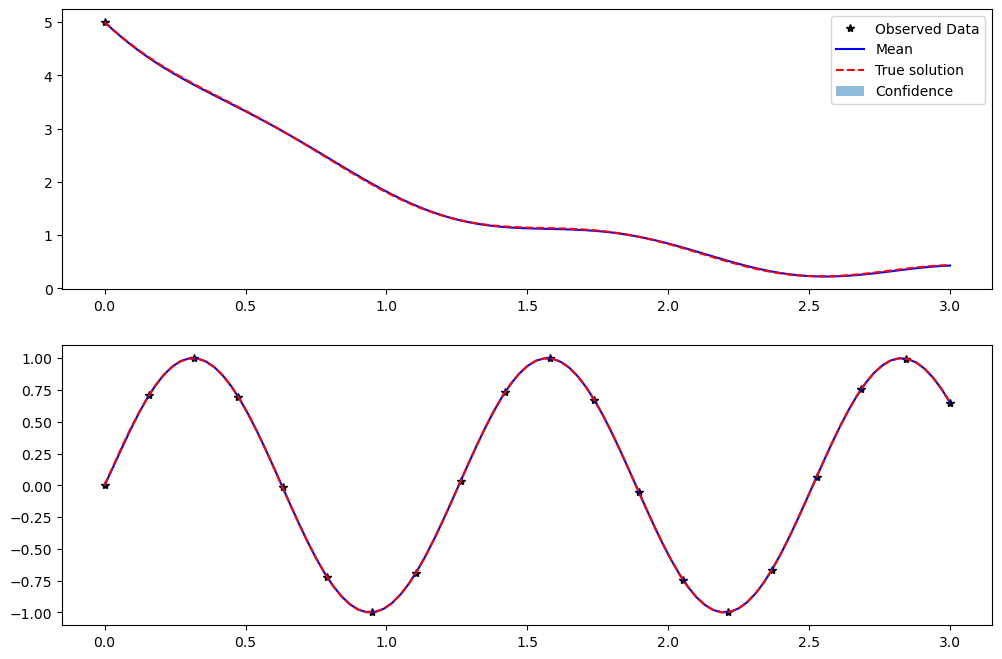

In [5]:
model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var(), gpytorch.settings.observation_nan_policy("mask"):
    observed_pred = model(full_test_x)

num_tasks = 2

def analytical_solution(t, T_a, R = 1, BC = 1):
    dt = t[1:]-t[:-1]
    dt = torch.cat([dt, dt[-1:]])
    return torch.stack([BC*torch.exp(-t/R) + torch.exp(-t/R)*torch.cumsum(torch.exp(t/R)*T_a(t)*dt, 0), T_a(t)], dim = -1)

import matplotlib.pyplot as plt
with torch.no_grad():
    f, ax = plt.subplots(num_tasks, 1, figsize=(12, 8))
    lower, upper = observed_pred.confidence_region()
    
    for i in range(num_tasks):
        mask = test_i == i
        train_mask = train_i == i
        ax[i].plot(train_x[train_mask].numpy(), train_y[train_mask].numpy(), 'k*')
        ax[i].plot(test_x[mask].numpy(), observed_pred.mean[mask].numpy(), 'b')
        ax[i].plot(test_x[mask].numpy(), analytical_solution(test_x[mask], T_a_true, R = 1, BC = train_y_0[0])[:,i].numpy(), 'r--')
        ax[i].fill_between(test_x[mask].numpy(), lower[mask].numpy(), upper[mask].numpy(), alpha=0.5)
    ax[-2].legend(['Observed Data', 'Mean', "True solution", 'Confidence'])


## The inverse problem
If we actually have data for both tasks, but do not know the value of R, we can solve the inverse problem (i.e. extimating R) with just a few adaptations from our previous way. Let's say we have a new trainings data set (which for convenience we'll simulate from the analytical solution with R = 2, so the true value of R will be 2) plus some measurement noise:

In [6]:

train_x_0 = torch.linspace(0,3, 20)
train_x_1 = torch.linspace(0,3, 20)
train_i_0 = torch.zeros_like(train_x_0)
train_i_1 = torch.ones_like(train_x_1)
train_x = torch.concatenate([train_x_0, train_x_1])
train_i = torch.cat([train_i_0, train_i_1])
full_train_x = torch.stack([train_x, train_i], dim=-1) #data must have structure N x (d+1); N = total number of data points, d = dimensions, 1=index to specify task


train_y = analytical_solution(train_x_0, T_a_true, R = 1, BC = 5.)
train_y = torch.cat([train_y[:,0], train_y[:,1]])
train_y += 0.1**2*torch.ones_like(train_y)

test_x_0 = torch.linspace(0, 3, 101)
test_x_1 = torch.linspace(0, 3, 101)
test_i_0 = torch.zeros_like(test_x_0)
test_i_1 = torch.ones_like(test_x_1)
test_x = torch.cat([test_x_0, test_x_1])
test_i = torch.cat([test_i_0, test_i_1])
full_test_x = torch.stack([test_x, test_i], dim=-1)

test_y = analytical_solution(test_x_0, T_a_true, R = 1, BC = 5.)
test_y = torch.cat([test_y[:,0], test_y[:,1]]) 

We can set up the model as before, only changing the parameter dictionary by making R learnable (i.e. changing the second entry to true). Since we know the noise level we can also fix this. We rain as before, but calculate a bayesian posterior distribution over the parameters using a Laplace approximation afterwards. To be 100% Bayesian we will define a prior, stating that we know R has to be between 0.1 and 10. Note that we need to include a constrain to this interval as well. 

In [7]:
#setup
new_parameters = {"R": [1., True, False],#gpytorch.constraints.Interval(0, 10)],
                "amplitude":[1., True, gpytorch.constraints.Positive()], 
                "lengthscale": [1., True, gpytorch.constraints.Positive()],}
num_tasks = 2
priors =None# {"R": gpytorch.priors.UniformPrior(0., 10.)}

sigma = 0.1
noise_tensor = sigma**2*torch.ones(train_y.shape[0])
likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(noise = noise_tensor)                                                                                                                              
model = ex.PCGP_Model(full_train_x, train_y, likelihood, new_parameters, priors = priors)

#training
#training
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1) 
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
training_iter = 50
for i in range(training_iter):
        optimizer.zero_grad()
        output = model(full_train_x)
        loss = -mll(output, train_y)
        loss.backward()
        if i%5==0:
            print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
        optimizer.step()
optimizer.zero_grad()
output = model(full_train_x)  
final_loss = -mll(output, train_y)*train_y.shape[0] #train_y.shape is important because otherwise only "loss per point"

#Laplace approximation
from PCGP.gpytorch.LaplaceApprox import laplace_approx

laplace_approximation = laplace_approx(new_parameters, model, final_loss)
covariance, hessian, parameter_index = laplace_approximation.covariance, laplace_approximation.hessian, laplace_approximation.parameter_index
MAP_estimates = laplace_approximation.MAP_estimates

Iter 1/50 - Loss: 6.708
Iter 6/50 - Loss: 2.055
Iter 11/50 - Loss: 0.263
Iter 16/50 - Loss: 0.017
Iter 21/50 - Loss: 0.027
Iter 26/50 - Loss: -0.051
Iter 31/50 - Loss: -0.034
Iter 36/50 - Loss: -0.036
Iter 41/50 - Loss: -0.055
Iter 46/50 - Loss: -0.059


We can now again make predictions and plot the solution to the forward problem, to make sure everything got fitted correctly. 

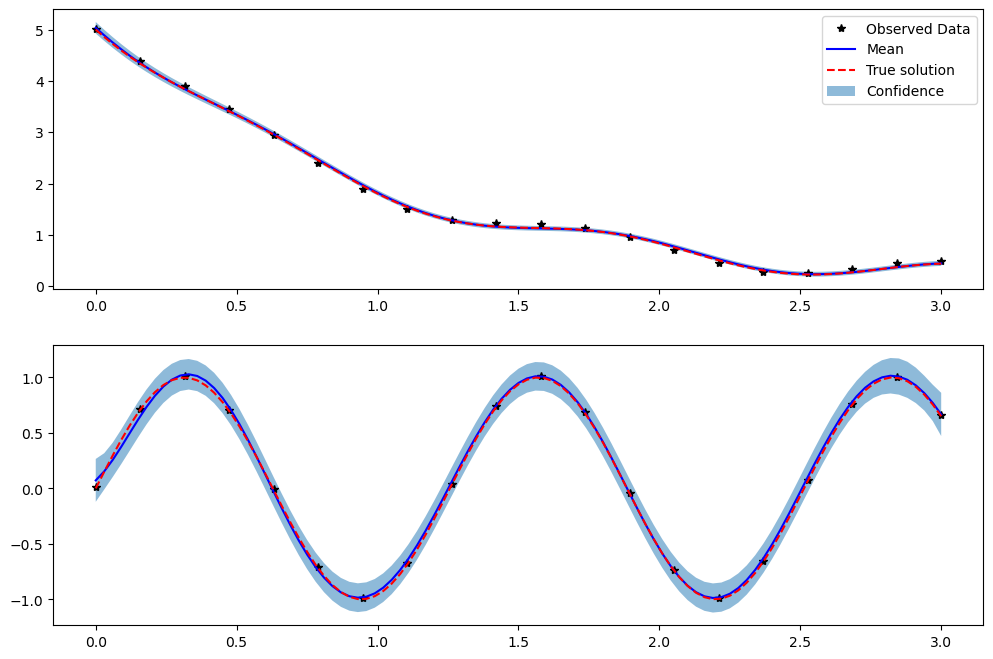

In [ ]:

model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var(), gpytorch.settings.observation_nan_policy("mask"):
    observed_pred = likelihood(model(full_test_x)) 

num_tasks = 2

def analytical_solution(t, T_a, R = 1, BC = 1):
    dt = t[1:]-t[:-1]
    dt = torch.cat([dt, dt[-1:]])
    return torch.stack([BC*torch.exp(-t/R) + torch.exp(-t/R)*torch.cumsum(torch.exp(t/R)*T_a(t)*dt, 0), T_a(t)], dim = -1)

import matplotlib.pyplot as plt
with torch.no_grad():
    f, ax = plt.subplots(num_tasks, 1, figsize=(12, 8))
    lower, upper = observed_pred.confidence_region()
    
    for i in range(num_tasks):
        mask = test_i == i
        train_mask = train_i == i
        ax[i].plot(train_x[train_mask].numpy(), train_y[train_mask].numpy(), 'k*')
        ax[i].plot(test_x[mask].numpy(), observed_pred.mean[mask].numpy(), 'b')
        ax[i].plot(test_x[mask].numpy(), analytical_solution(test_x[mask], T_a_true, R = 1, BC = train_y_0[0])[:,i].numpy(), 'r--')
        ax[i].fill_between(test_x[mask].numpy(), lower[mask].numpy(), upper[mask].numpy(), alpha=0.5)
    ax[-2].legend(['Observed Data', 'Mean', "True solution", 'Confidence'])


The estimated parameter value for R is stored in the dictionary parameter_during_training in the last entry for the first parameter, and the joint covariance of the estimated parameters is stored in laplace_covariance. If you are unsure about the order of the parameters have a look at used_parameters. Since R is the first entry there, laplace_covariance[0,0] is the variance of R when we marginalize over the calibration parameters. Therefore: 

R = 1.009 +-0.025


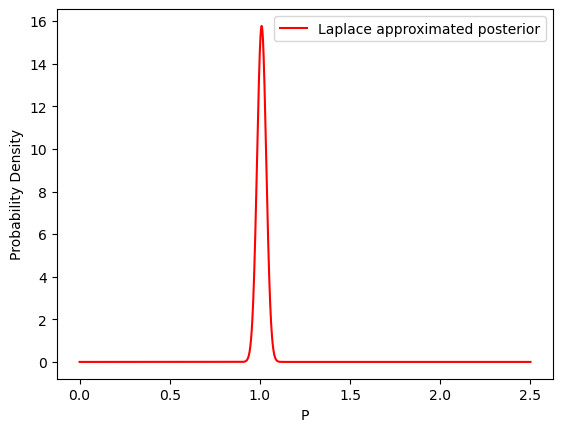

In [11]:
idx = parameter_index["R"]

R_0 = MAP_estimates[idx].numpy()
width = torch.sqrt(covariance[idx, idx]).numpy()
print(r"""R = %.3f +-%.3f""" %(R_0, width))
R_grid = np.linspace(0, 2.5, 2000)
pdf = np.exp(-(R_grid-R_0)**2/(2*width**2)) / np.sqrt(2 * np.pi)/width

plt.plot(R_grid, pdf, 'r-', label='Laplace approximated posterior')
plt.xlabel('P')
plt.ylabel('Probability Density')
plt.legend()
#plt.xlim([1.5, 2.5])

Great we did it, we found a posterior distribution that accurately estimated our parameter! To be completely sure we can also compute this posterior using MCMC to check for any skewedness etc, but for this, we will have to write a new kernel class and include priors for every parameter that is sampled (for the calibration parameters we just use flat priors as well, but feel free to try different ones):

In [13]:
from PCGP import PCGP_Builder_jax

builder = PCGP_Builder_jax()
builder.add_kernel(B,  number_of_input_dimensions=1, shared_base_kernel = True)
builder.write("Model_2_numpyro", output_dir = output_dir)

Kernel and model written to: /home/johanna/Documents/PhD/project/github/PCGP/Tutorials/Tutorial_ver1.1/Model_2_numpyro.py


In order to sample the parameters using numpyro, we need to convert everything into jax arrays, and change the structure of train_y so that it is one dimensional; the first n entries are the first task, the second n entries are the second one. Note that you can change MCMC specific parameters such as warmup steps etc in the numpyro file, and also note that for efficiency reasons it is recommended to try this in a .py file. For now, we will show it with a small sample size and fix the calibration parameters to minimize the phase space. Furthermore, to ensure sampling in a reasonable environment, we set the initial values of the MCMC chain to the learned parameter values from gpytorch. This is not strictly necessary but greatly enhances performance.

In [24]:
import Model_2_numpyro as mcmc
import jax.numpy as jnp
import jax.random as random
import jax
from functools import partial
import PCGP.jax.grid as grid
import PCGP.jax.numpyro as npyro
import numpyro.distributions as dist 

rng_key = random.PRNGKey(0)

full_train_x_jax = jnp.array(full_train_x)
train_y_jax = jnp.array(train_y)
full_test_y_jax = jnp.array(full_test_x)

structure = grid.build_structure(full_train_x_jax, full_train_x_jax, num_tasks=num_tasks)
compiled_kernel = jax.jit(partial(mcmc.kernel, structure=structure))

init_values = {key: jnp.array(MAP_estimates[parameter_index[key]]) for key in parameter_index}
priors = {"R": dist.Uniform(0.000, 4), "lengthscale": dist.Uniform(0.001, 10), "amplitude": dist.Uniform(0.001, 10)} #choosing a flat prior for all parameters  

  
compiled_model = npyro.build_model(compiled_kernel, priors = priors)
samples = npyro.run_inference(compiled_model, 
                             rng_key, #pse
                             full_train_x_jax, 
                             train_y_jax, 
                             num_samples =1000, 
                             sigma = sigma,
                             priors = priors,
                             init_values = init_values,
                             fixed_params={})


R_samples = jnp.squeeze(samples["R"])


sample: 100%|██████████| 2000/2000 [00:10<00:00, 186.49it/s, 7 steps of size 5.32e-01. acc. prob=0.91]



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
            R      1.00      0.02      1.00      0.95      1.03    715.19      1.00
    amplitude      8.11      1.46      8.48      5.99     10.00    741.50      1.00
  lengthscale      0.50      0.06      0.50      0.40      0.60    581.65      1.00

Number of divergences: 0
MCMC elapsed time: 13.922528743743896


Finally, we can plot a histogram and compare it to the Laplace approximation:

0.049669567


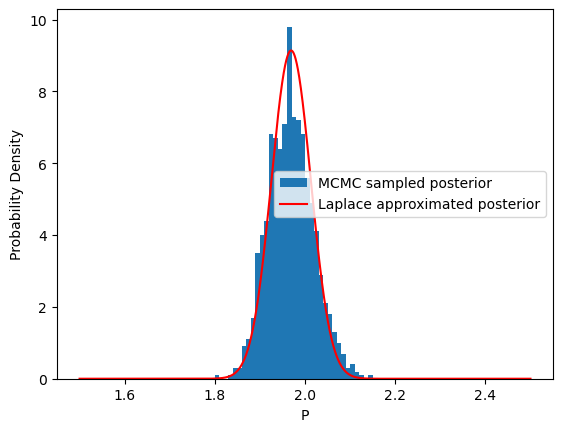

In [190]:
print(jnp.sqrt(R_samples.var()))
bin_width = 0.01
bin_edges = np.arange(1.5, 2.5 + bin_width, bin_width)
plt.hist(R_samples, bins = bin_edges, density = True, label = "MCMC sampled posterior")

plt.plot(R_grid, pdf, 'r-', label='Laplace approximated posterior')
plt.xlabel('P')
plt.ylabel('Probability Density')
plt.legend()
#plt.xlim([1.9, 2.1])

## 